In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../Datasets/Fashion_Trends.csv")
df

,Brand,Description,Product_ID,Discount_Price,Original_Price,Gender,Category,Discounted_amount,Discount_Percentage,Product_Name,Price_Segment,Discount_Tier
0,performax,Typographic Print Track Pants with Insert Pockets,441136763008,974,1299,Men,Activewear,325,25.02,Track Pants,Mid (₹500–₹1499),Moderate (20-40%)
1,performax,Low-Top Lace-Up Sports Shoes,450137679013,1499,1499,Men,Activewear,0,0.00,Sports Shoes,Mid (₹500–₹1499),No Discount
2,teamspirit,Colorblock Crew-Neck T-shirt,441133214008,461,549,Men,Activewear,88,16.03,Crew-Neck T-shirt,Mid (₹500–₹1499),Light (10-20%)
3,performax,Camouflage Print Joggers with Insert Pockets,441134776020,1189,1699,Men,Activewear,510,30.02,Print Joggers,Premium (₹1500–₹3999),Moderate (20-40%)
4,teamspirit,Reflective Colourblock Crew-Neck T-shirt,441136539020,425,599,Men,Activewear,174,29.05,Crew-Neck T-shirt,Mid (₹500–₹1499),Moderate (20-40%)
...,...,...,...,...,...,...,...,...,...,...,...,...
31577,ajio,Printed Top with Raglan Sleeves,460328028004,1299,1299,Women,Westernwear,0,0.00,Printed Top,Mid (₹500–₹1499),No Discount
31578,ajio,Striped Cropped Pants with Belt,460328036004,2099,2099,Women,Westernwear,0,0.00,Cropped Pants,Premium (₹1500–₹3999),No Discount
31579,ajio,Striped City Shorts with Belt,460328005002,1499,1499,Women,Westernwear,0,0.00,City Shorts,Mid (₹500–₹1499),No Discount
31580,ajio,Denim Jacket with Frayed Hemline,460328651009,2999,2999,Women,Westernwear,0,0.00,Denim Jacket,Premium (₹1500–₹3999),No Discount


In [3]:
df.dtypes

Brand                   object
Description             object
Product_ID               int64
Discount_Price           int64
Original_Price           int64
Gender                  object
Category                object
Discounted_amount        int64
Discount_Percentage    float64
Product_Name            object
Price_Segment           object
Discount_Tier           object
dtype: object

In [4]:
df.columns

Index(['Brand', 'Description', 'Product_ID', 'Discount_Price',
       'Original_Price', 'Gender', 'Category', 'Discounted_amount',
       'Discount_Percentage', 'Product_Name', 'Price_Segment',
       'Discount_Tier'],
      dtype='object')

In [5]:
df.isnull().sum()

Brand                  0
Description            0
Product_ID             0
Discount_Price         0
Original_Price         0
Gender                 0
Category               0
Discounted_amount      0
Discount_Percentage    0
Product_Name           0
Price_Segment          0
Discount_Tier          0
dtype: int64

In [6]:
df.describe()


,Product_ID,Discount_Price,Original_Price,Discounted_amount,Discount_Percentage
count,3.158200e+04,31582.000000,31582.000000,31582.000000,31582.000000
mean,4.439001e+11,929.759832,1418.094769,488.334938,32.979031
std,5.715579e+09,727.207471,945.684511,544.062245,24.667178
min,4.200088e+11,75.000000,149.000000,0.000000,0.000000
25%,4.411142e+11,479.000000,799.000000,0.000000,0.000000
50%,4.411360e+11,735.000000,1299.000000,356.000000,35.040000
75%,4.501273e+11,1199.000000,1799.000000,749.000000,50.930000
max,4.608526e+11,16999.000000,19999.000000,11999.000000,85.010000


In [7]:
df.Discount_Percentage.fillna(0, inplace=True)
df.Discount_Tier.fillna('No Discount', inplace=True)
df.Price_Segment.fillna('Unknown', inplace=True)

In [8]:
df

,Brand,Description,Product_ID,Discount_Price,Original_Price,Gender,Category,Discounted_amount,Discount_Percentage,Product_Name,Price_Segment,Discount_Tier
0,performax,Typographic Print Track Pants with Insert Pockets,441136763008,974,1299,Men,Activewear,325,25.02,Track Pants,Mid (₹500–₹1499),Moderate (20-40%)
1,performax,Low-Top Lace-Up Sports Shoes,450137679013,1499,1499,Men,Activewear,0,0.00,Sports Shoes,Mid (₹500–₹1499),No Discount
2,teamspirit,Colorblock Crew-Neck T-shirt,441133214008,461,549,Men,Activewear,88,16.03,Crew-Neck T-shirt,Mid (₹500–₹1499),Light (10-20%)
3,performax,Camouflage Print Joggers with Insert Pockets,441134776020,1189,1699,Men,Activewear,510,30.02,Print Joggers,Premium (₹1500–₹3999),Moderate (20-40%)
4,teamspirit,Reflective Colourblock Crew-Neck T-shirt,441136539020,425,599,Men,Activewear,174,29.05,Crew-Neck T-shirt,Mid (₹500–₹1499),Moderate (20-40%)
...,...,...,...,...,...,...,...,...,...,...,...,...
31577,ajio,Printed Top with Raglan Sleeves,460328028004,1299,1299,Women,Westernwear,0,0.00,Printed Top,Mid (₹500–₹1499),No Discount
31578,ajio,Striped Cropped Pants with Belt,460328036004,2099,2099,Women,Westernwear,0,0.00,Cropped Pants,Premium (₹1500–₹3999),No Discount
31579,ajio,Striped City Shorts with Belt,460328005002,1499,1499,Women,Westernwear,0,0.00,City Shorts,Mid (₹500–₹1499),No Discount
31580,ajio,Denim Jacket with Frayed Hemline,460328651009,2999,2999,Women,Westernwear,0,0.00,Denim Jacket,Premium (₹1500–₹3999),No Discount


In [9]:
df.Original_Price = pd.to_numeric(df.Original_Price, errors='coerce')
df.Discount_Percentage = pd.to_numeric(df.Discount_Percentage, errors='coerce')
df.Discounted_amount = pd.to_numeric(df.Discounted_amount, errors='coerce')

In [10]:
df

,Brand,Description,Product_ID,Discount_Price,Original_Price,Gender,Category,Discounted_amount,Discount_Percentage,Product_Name,Price_Segment,Discount_Tier
0,performax,Typographic Print Track Pants with Insert Pockets,441136763008,974,1299,Men,Activewear,325,25.02,Track Pants,Mid (₹500–₹1499),Moderate (20-40%)
1,performax,Low-Top Lace-Up Sports Shoes,450137679013,1499,1499,Men,Activewear,0,0.00,Sports Shoes,Mid (₹500–₹1499),No Discount
2,teamspirit,Colorblock Crew-Neck T-shirt,441133214008,461,549,Men,Activewear,88,16.03,Crew-Neck T-shirt,Mid (₹500–₹1499),Light (10-20%)
3,performax,Camouflage Print Joggers with Insert Pockets,441134776020,1189,1699,Men,Activewear,510,30.02,Print Joggers,Premium (₹1500–₹3999),Moderate (20-40%)
4,teamspirit,Reflective Colourblock Crew-Neck T-shirt,441136539020,425,599,Men,Activewear,174,29.05,Crew-Neck T-shirt,Mid (₹500–₹1499),Moderate (20-40%)
...,...,...,...,...,...,...,...,...,...,...,...,...
31577,ajio,Printed Top with Raglan Sleeves,460328028004,1299,1299,Women,Westernwear,0,0.00,Printed Top,Mid (₹500–₹1499),No Discount
31578,ajio,Striped Cropped Pants with Belt,460328036004,2099,2099,Women,Westernwear,0,0.00,Cropped Pants,Premium (₹1500–₹3999),No Discount
31579,ajio,Striped City Shorts with Belt,460328005002,1499,1499,Women,Westernwear,0,0.00,City Shorts,Mid (₹500–₹1499),No Discount
31580,ajio,Denim Jacket with Frayed Hemline,460328651009,2999,2999,Women,Westernwear,0,0.00,Denim Jacket,Premium (₹1500–₹3999),No Discount


In [11]:
df.dtypes

Brand                   object
Description             object
Product_ID               int64
Discount_Price           int64
Original_Price           int64
Gender                  object
Category                object
Discounted_amount        int64
Discount_Percentage    float64
Product_Name            object
Price_Segment           object
Discount_Tier           object
dtype: object

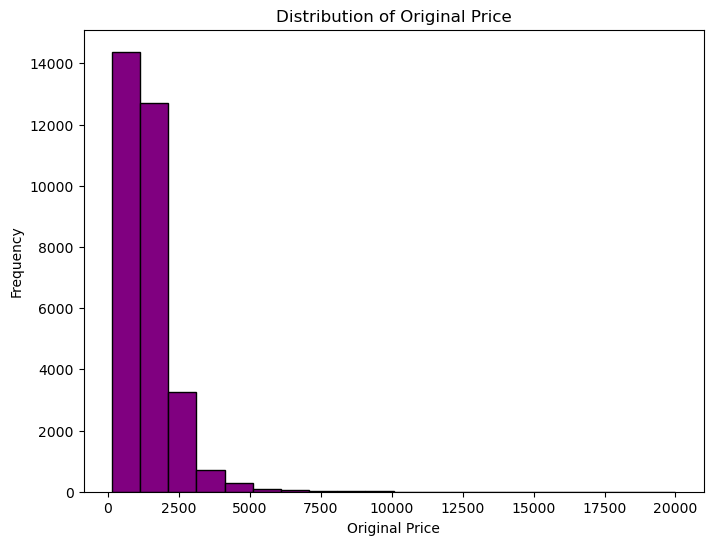

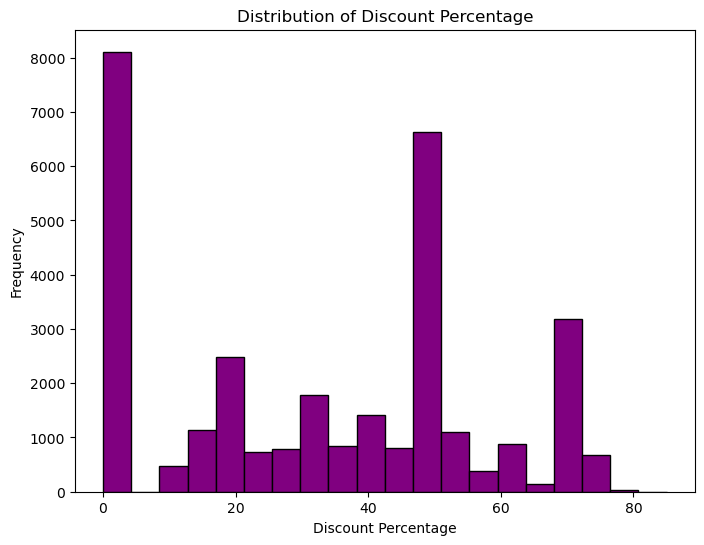

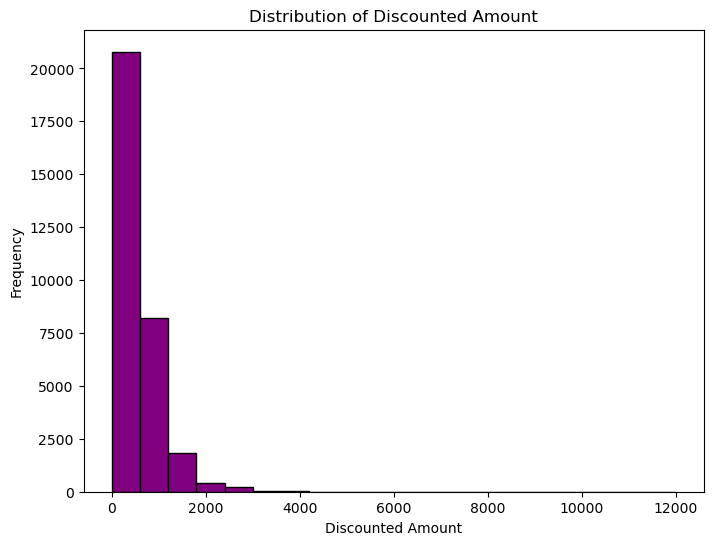

In [14]:
plt.figure(figsize=(8,6))
plt.hist(df.Original_Price, bins=20, color='purple', edgecolor='black')
plt.title('Distribution of Original Price')
plt.xlabel('Original Price')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,6))
plt.hist(df.Discount_Percentage, bins=20, color='purple', edgecolor='black')
plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount Percentage')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8,6))
plt.hist(df.Discounted_amount, bins=20, color='purple', edgecolor='black')
plt.title('Distribution of Discounted Amount')
plt.xlabel('Discounted Amount')
plt.ylabel('Frequency')
plt.show()

**Price Distribution** :Most products have prices in the lower range (below ₹3000).Very few products have high prices above ₹5000.This shows that most fashion items are affordable.
**Discount Percentage** : Most products have discounts between 10% to 50%.Very high discounts (above 70%) are less common.This shows brands mostly offer moderate discounts.
**Discounted_amount** : Most discount amounts are small (below ₹2000).Very few products have large discount amounts.This indicates limited high-value discounts.

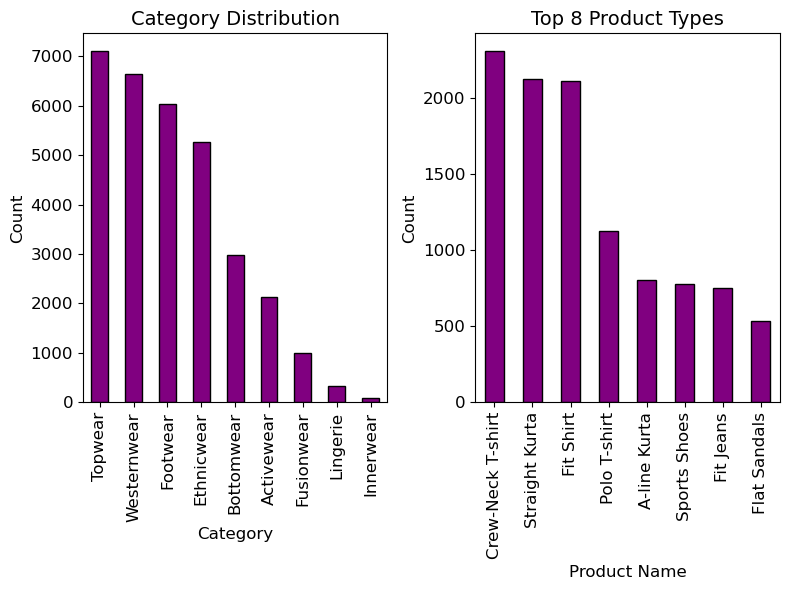

In [15]:
plt.figure(figsize=(8,6))

plt.subplot(121)
df.Category.value_counts().plot(kind='bar', color='purple', edgecolor='black')
plt.title("Category Distribution", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

plt.subplot(122)
df.Product_Name.value_counts().head(8).plot(kind='bar', color='purple', edgecolor='black')
plt.title("Top 8 Product Types", fontsize=14)
plt.xlabel("Product Name", fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

**Category Distribution** : Topwear has the highest count approx 7000, followed by Westernwear and Footwear.Categories like Lingerie and Innerwear have very low counts.This shows that most products belong to popular daily wear categories.
**Top 8 Product Types** : Crew Neck T-shirts have the highest count approx 2300, followed by Kurtas and Fit Shirts approx 2100 each.Products like Flat Sandals have the lowest count approx 500.This shows that casual and traditional wear are most popular.
**Top 8 Brands** : Performax has the highest number of products approx 3000, followed by Team Spirit and DNMX. Other brands have similar but lower counts approx 1200–1800.This indicates that a few brands dominate the market.   

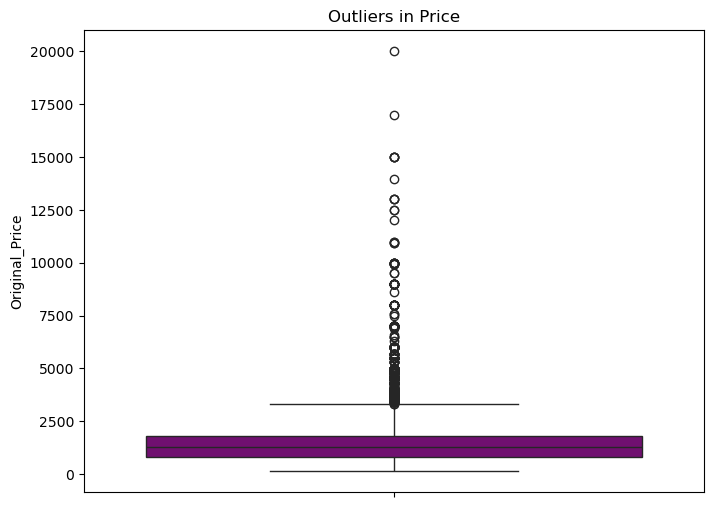

In [16]:
plt.figure(figsize=(8,6))
sb.boxplot(y=df.Original_Price, color = 'purple')   
plt.title("Outliers in Price")
plt.show()

Most product prices lie between ₹500 to ₹2000 (main range).There are many outliers above ₹5000, with some reaching up to ₹20000.This shows that a few products are highly expensive compared to the majority.

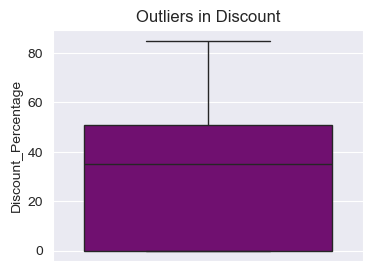

In [90]:
plt.figure(figsize=(4,3))
sb.boxplot(y=df.Discount_Percentage, color = 'purple')
plt.title("Outliers in Discount")
plt.show()

Most discounts lie between 0% to 50%, with a median around 35%.The maximum discount goes up to around 80–85%.There are very few extreme discounts, showing most offers are moderate.

Brand
performax             3029
teamspirit            1908
dnmx                  1757
netplay               1698
avaasa-mix-n-match    1507
john-players          1224
hi-attitude           1191
w                     1179
fig                   1110
lee-cooper             927
Name: count, dtype: int64


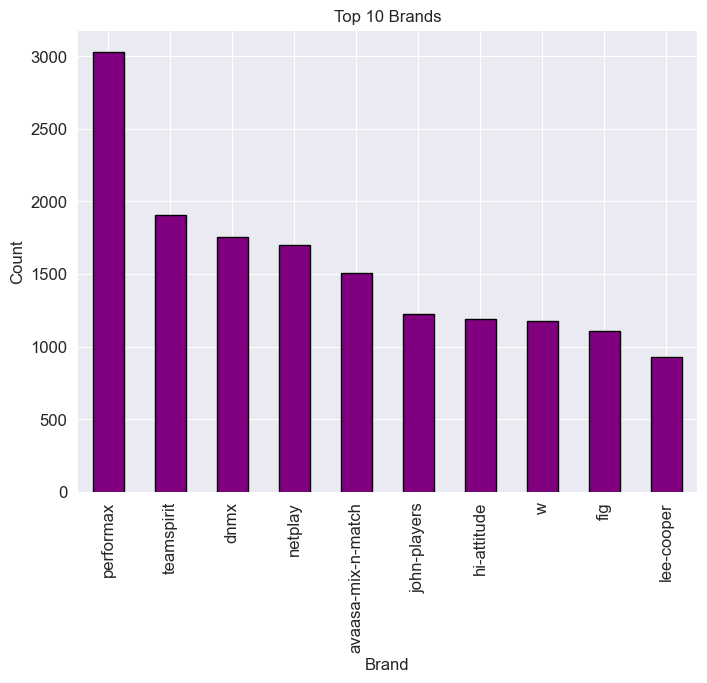

In [85]:
plt.figure(figsize=(8,6))
top_brands = df.Brand.value_counts()
print(top_brands.head(10))

top_brands.head(10).plot(kind='bar', color='purple', edgecolor='black')
plt.title("Top 10 Brands")
plt.xticks(rotation=90,fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Brand",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.show()

Category
Activewear     2134
Bottomwear     2984
Ethnicwear     5265
Footwear       6030
Fusionwear      997
Innerwear        96
Lingerie        325
Topwear        7110
Westernwear    6641
dtype: int64


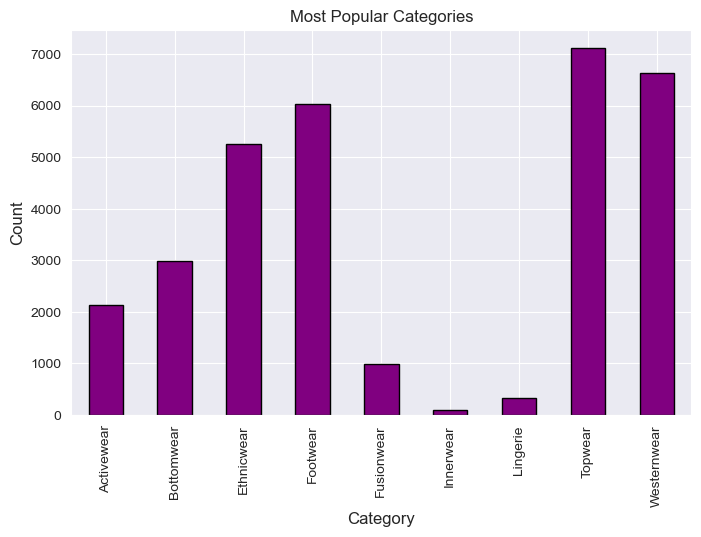

In [69]:
plt.figure(figsize=(8,5))
cat_count = df.groupby('Category').size()

print(cat_count)

cat_count.plot(kind='bar', color='purple',edgecolor='black')
plt.title("Most Popular Categories")
plt.xlabel("Category",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.show()

Performax is the top brand with around 3000 products, significantly higher than others.Teamspirit approx 1900 and Dmx approx 1750 follow, showing moderate presence in the dataset.Brands like John Players, Hi-Attitude, and W have lower counts (~1150–1200), indicating fewer products compared to top brands.

In [18]:
price_cat = df.groupby(['Price_Segment','Category']).size()

price_cat

Price_Segment          Category   
Low (<₹500)            Activewear      156
                       Bottomwear       79
                       Ethnicwear      588
                       Footwear        725
                       Fusionwear       25
                       Innerwear        83
                       Lingerie        153
                       Topwear         515
                       Westernwear     648
Luxury (₹4000+)        Activewear        9
                       Bottomwear        3
                       Ethnicwear      227
                       Footwear        182
                       Fusionwear       61
                       Topwear          15
                       Westernwear       4
Mid (₹500–₹1499)       Activewear     1237
                       Bottomwear     1414
                       Ethnicwear     2506
                       Footwear       2766
                       Fusionwear      532
                       Innerwear        11
                   

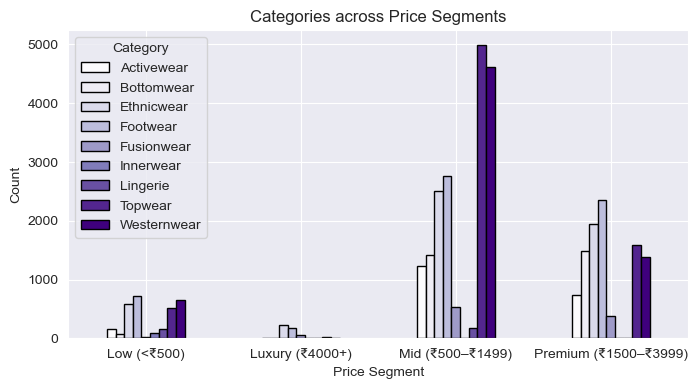

In [96]:
sb.set_style("darkgrid")  

price_cat.unstack().plot(kind='bar', figsize=(8,4), colormap='Purples', edgecolor='black')

plt.title("Categories across Price Segments")
plt.xticks(rotation=0)
plt.xlabel("Price Segment")
plt.ylabel("Count")

plt.show()

Mid segment (₹500–₹1499) dominates with the highest counts, especially Topwear approx 5000 and Westernwear approx 4600.Premium segment (₹1500–₹3999) also shows strong presence, with Footwear approx 2300 and Bottomwear approx 1900 leading. Low and Luxury segments have very few products, indicating most items are focused in mid-range pricing.

Product_Name
Crew-Neck T-shirt         2312
Straight Kurta            2126
Fit Shirt                 2117
Polo T-shirt              1126
A-line Kurta               803
Sports Shoes               779
Fit Jeans                  755
Flat Sandals               537
Thong-Strap Flip-Flops     516
Running Shoes              503
Name: count, dtype: int64


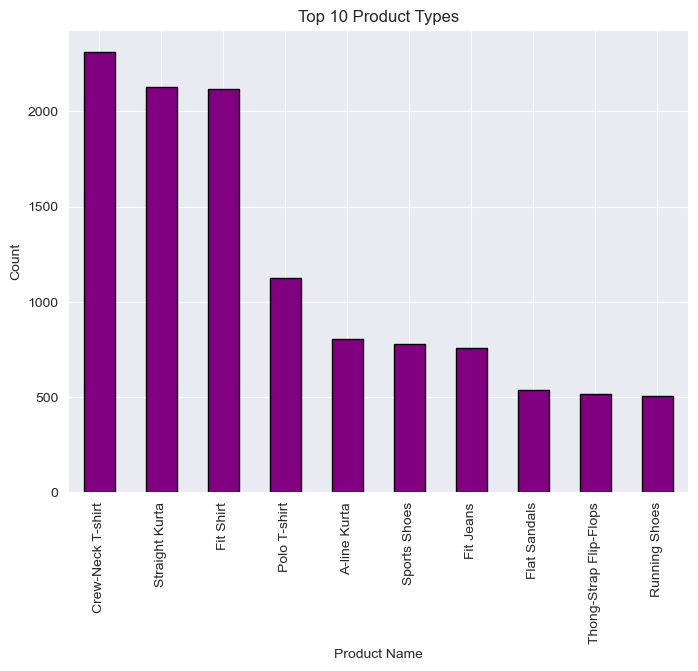

In [88]:
top_products = df.Product_Name.value_counts()

plt.figure(figsize=(8,6))
print(top_products.head(10))

top_products.head(10).plot(kind='bar', color='purple', edgecolor='black')
plt.title("Top 10 Product Types")
plt.xlabel("Product Name")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

Crew-Neck T-shirt is the most common product (approx 2300), followed by Straight Kurta and Fit Shirt (approx 2100 each).Polo T-shirt has moderate presence (approx 1100), while A-line Kurta, Sports Shoes, and Fit Jeans are lower (approx 700–800). Flat Sandals have the least count (approx500), indicating lower popularity compared to other product types.

In [21]:
cat_product = df.groupby(['Category','Product_Name']).size()
print(cat_product)

Category     Product_Name          
Activewear   -On Flip-Flops            1
             A-line Dress              1
             Ankle-Length Joggers      3
             Ankle-Length Treggings    4
             Bardot Top                1
                                      ..
Westernwear  tank Top                  1
             teal xs                   1
             ustainable Joggers        1
             white s                   1
             white xs                  1
Length: 2432, dtype: int64


Discount_Tier
 No Discount           8107
Deep (>40%)           15194
Light (10-20%)         1621
Moderate  (20-40%)     6660
dtype: int64


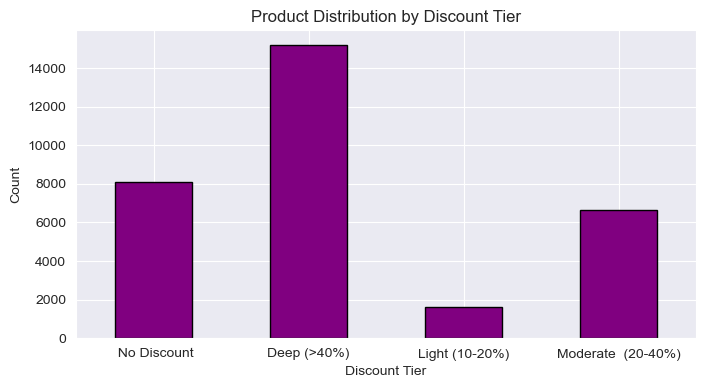

In [97]:
plt.figure(figsize=(8,4))

discount_tier = df.groupby('Discount_Tier').size()
print(discount_tier)
discount_tier.plot(kind='bar', color='purple', edgecolor='black')
plt.title("Product Distribution by Discount Tier")
plt.xlabel("Discount Tier")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

Deep discounts (>40%) dominate with around 15,000 products, showing heavy reliance on high discounting.Light discounts (10–20%) are least common with only about 1,500 products.No discount (approx 8,000) and moderate discounts (~6,500) also have significant presence, indicating mixed pricing strategies.

Product_Name
Brocade Angarakha     80.00
Brocade Tunic         80.00
Chanderi Top          79.99
Chanderi Kurta        79.99
Fit Sweater           74.99
Olive Gillet          74.99
Round-Neck Ponchos    74.99
Mustard Trousers      74.99
Name: Discount_Percentage, dtype: float64


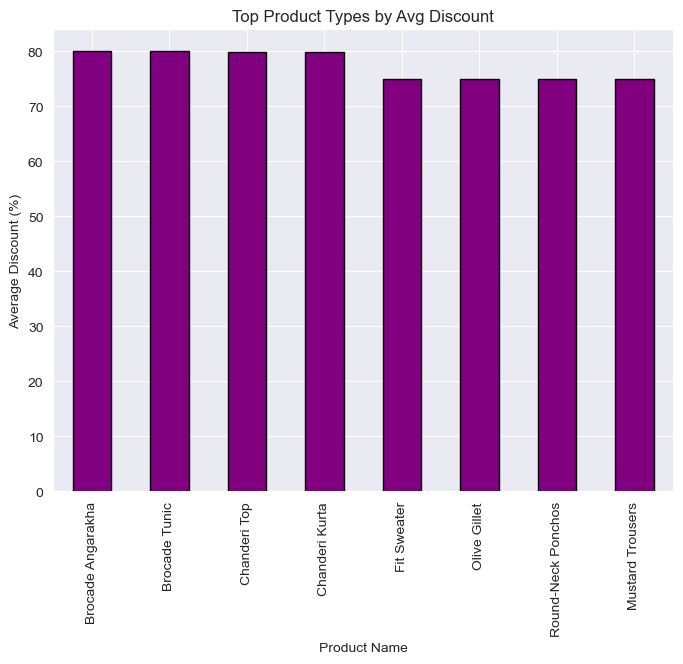

In [73]:
avg_discount = df.groupby('Product_Name')['Discount_Percentage'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,6))
print(avg_discount.head(8))

avg_discount.head(8).plot(kind='bar', color='purple',edgecolor='black')
plt.title("Top Product Types by Avg Discount")
plt.xlabel("Product Name")
plt.ylabel("Average Discount (%)")
plt.xticks(rotation=90)
plt.show()

Top products like Brocade Angrakha, Brocade Tunic, Chanderi items offer the highest discounts (~80%).Other products like Fit Sweater, Olive Gillet, Ponchos have slightly lower discounts around ~75%. Overall, all top products have very high discounts (75–80%), showing aggressive pricing strategy.

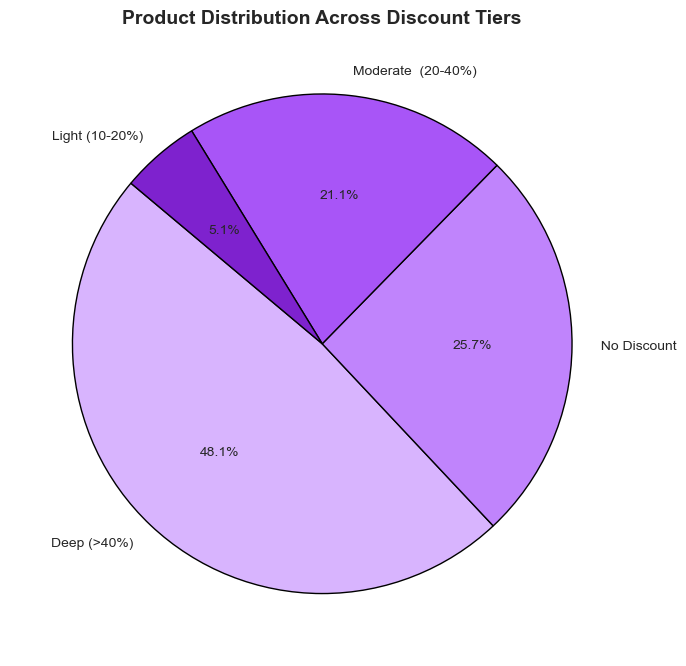

In [99]:
discount_counts = df.Discount_Tier.value_counts()

plt.figure(figsize=(7,7))

colors = ['#d8b4fe','#c084fc','#a855f7','#7e22ce']  # nice purple shades

discount_counts.plot(kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor':'black', 'linewidth':1}
)

plt.title("Product Distribution Across Discount Tiers", fontsize=14, fontweight='bold')
plt.ylabel("")

plt.tight_layout()
plt.show()

A large share of products are offered with Deep Discounts (>40%), accounting for 48.1% of the total assortment, showing an aggressive promotional pricing strategy.Meanwhile, 25.7% of products have no discount, 21.1% fall under moderate discounts (20–40%), and only 5.1% receive light discounts (10–20%).This suggests that the platform relies heavily on high discounting to attract customers and drive conversions.

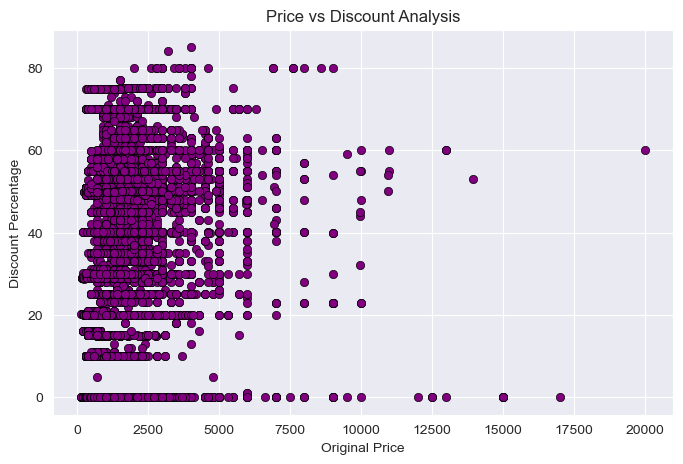

In [108]:
plt.figure(figsize=(8,5))
sb.scatterplot(x='Original_Price', y='Discount_Percentage', data=df, color='purple', edgecolor='black')

plt.title("Price vs Discount Analysis")
plt.xlabel("Original Price")
plt.ylabel("Discount Percentage")

plt.show()

No strong correlation: Discounts are spread across all price ranges, not dependent on price. Most products priced between ₹1,000–₹5,000 have discounts around 20%–60%. Some high-priced items (₹10,000+) also offer high discounts, but are fewer in number. Discounts are applied across all price levels, but are most concentrated in mid-range products.

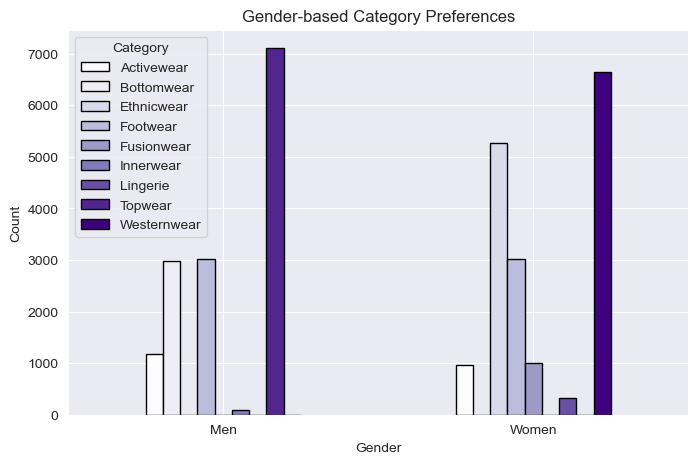

In [105]:
gender_cat = df.groupby(['Gender','Category']).size()
gender_cat 
gender_cat.unstack().plot(kind='bar', figsize=(8,5), colormap='Purples',edgecolor='black')

plt.title("Gender-based Category Preferences")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

Topwear is most preferred by both genders (Men approx 7100, Women approx 6600).Women show higher preference for Ethnicwear (approx 5300) compared to men (approx 4300).Men prefer Bottomwear & Footwear slightly more, while Fusionwear & Lingerie are minimal. Both genders favor topwear, but women lean more toward ethnic styles, while men show more balance across categories.

Gender
Men      33.31903
Women    32.69499
Name: Discount_Percentage, dtype: float64


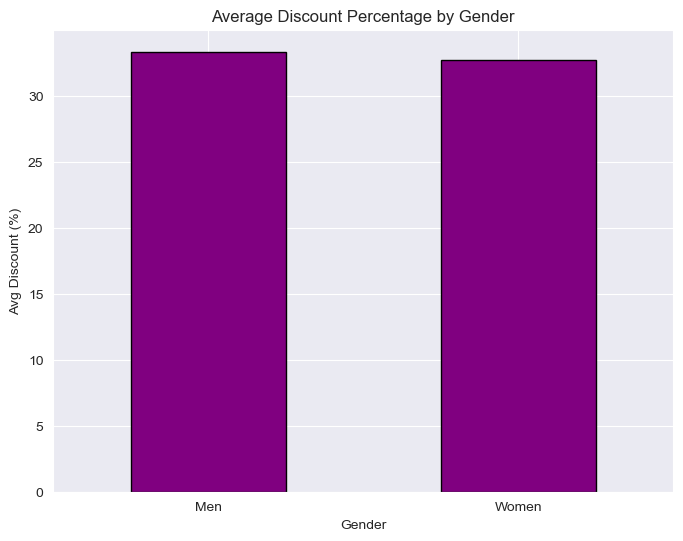

In [76]:
avg_gender_discount = df.groupby('Gender')['Discount_Percentage'].mean()
print(avg_gender_discount)

plt.figure(figsize=(8,6))
avg_gender_discount.plot(kind='bar', color='purple', edgecolor='black')
plt.title("Average Discount Percentage by Gender")
plt.xlabel("Gender")
plt.ylabel("Avg Discount (%)")
plt.xticks(rotation=0)

plt.show()

Men get an average discount of about **33.2%**, while women get around **32.7%**.
The difference is very small only about **0.5%**, so both men and women receive almost the same discounts.

Price_Segment
Mid (₹500–₹1499)         18237
Premium (₹1500–₹3999)     9872
Low (<₹500)               2972
Luxury (₹4000+)            501
Name: count, dtype: int64


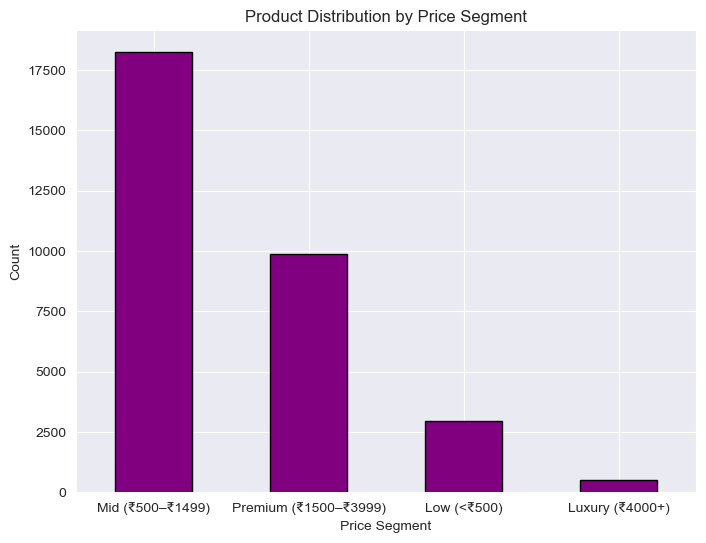

In [77]:
price_seg = df.Price_Segment.value_counts()

print(price_seg)

plt.figure(figsize=(8,6))
price_seg.plot(kind='bar', color='purple', edgecolor='black')

plt.title("Product Distribution by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

The Mid price segment (₹500–₹1499) has the highest number of products with ~18,200 items, followed by the Premium segment (₹1500–₹3999) with approx 9,800 items.The Low segment (<₹500) has only approx 2,900 products, while Luxury (₹4000+) is the smallest with just approx 500 products. This shows that the product portfolio is strongly focused on mid-range pricing, with limited emphasis on budget and luxury categories.

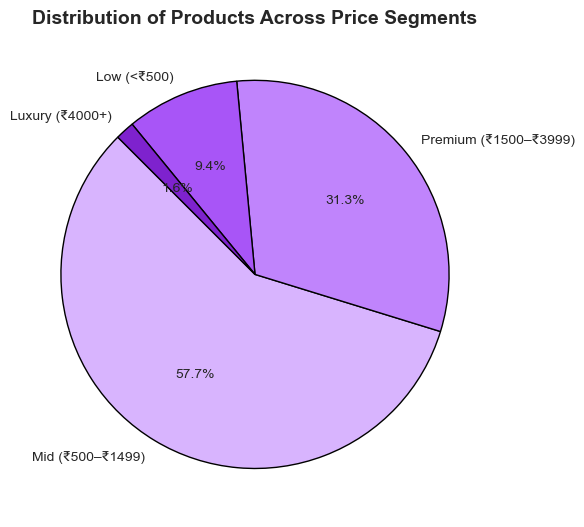

In [121]:
plt.figure(figsize=(6,6))
price_seg.plot(kind='pie',autopct='%1.1f%%',startangle=135,colors = ['#d8b4fe','#c084fc','#a855f7','#7e22ce'],wedgeprops={'edgecolor': 'black', 'linewidth': 1} )

plt.title("Distribution of Products Across Price Segments", fontsize=14, fontweight='bold')
plt.ylabel("")  
plt.yticks(rotation = 0)

plt.tight_layout()
plt.show()


The product portfolio is heavily concentrated in the Mid price segment (₹500–₹1499), which accounts for 57.7% of all products, showing that the brand assortment mainly targets value-conscious mass customers.The Premium segment (₹1500–₹3999) contributes 31.3%, while Low-priced products (<₹500) make up only 9.4% and Luxury (₹4000+) is very limited at 1.6%.This indicates a strong mid-market positioning, with some premium presence but very little focus on entry-level or luxury products.

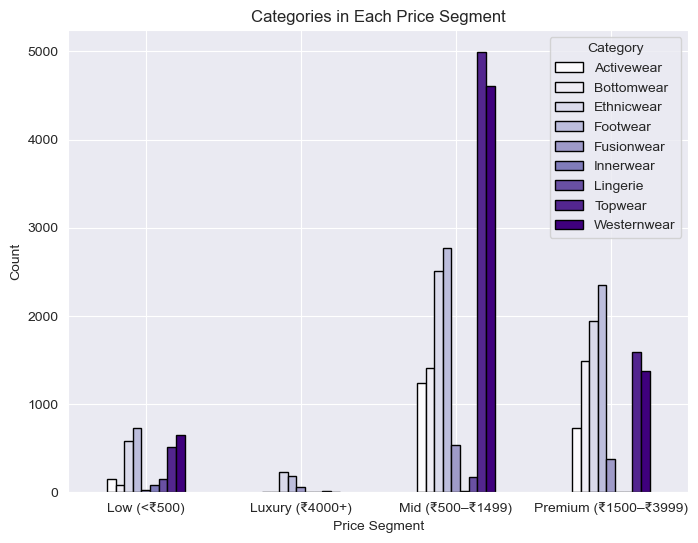

In [78]:
pd.crosstab(df.Price_Segment, df.Category).plot(kind='bar',figsize=(8,6),colormap='Purples',edgecolor='black')

plt.title("Categories in Each Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

Topwear (approx 5000) and Westernwear (approx 4500) dominate in the mid-price segment.  
In the premium segment, Ethnicwear (approx 2300) and Footwear (approx 2400) have strong presence.  
Luxury segment has very few products across all categories.

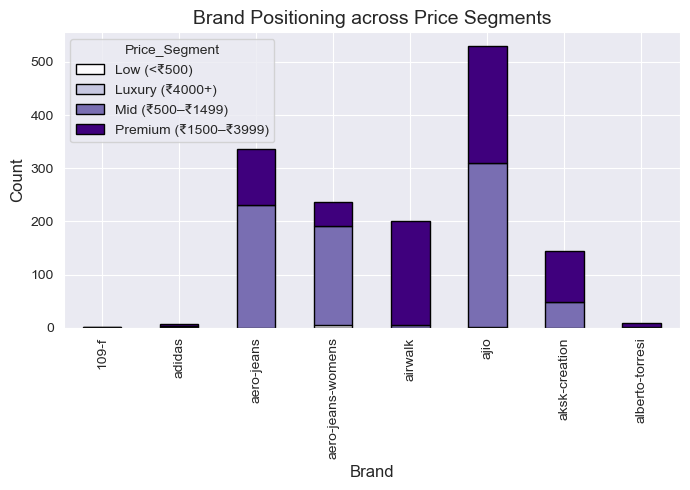

In [111]:
brand_price = pd.pivot_table(df,index='Brand',columns='Price_Segment',values='Product_ID',aggfunc='count').fillna(0)

brand_price.head(8).plot(kind='bar',stacked=True,figsize=(7,5),colormap='Purples',edgecolor='black')
plt.title("Brand Positioning across Price Segments", fontsize=14)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Ajio has the highest product count (approx 530), mainly in mid and premium price segments.  
Aero-jeans (approx 330) and aero-jeans-womens (approx 230) also focus mostly on mid-range products.  
Airwalk (approx 200) and aksk-creation (approx 140) are more focused on premium segments, while luxury items are very few across all brands.